# Alpamayo-R1 Demo

This notebook will load some example data from the NVIDIA [PhysicalAI-AV Dataset](https://huggingface.co/datasets/nvidia/PhysicalAI-Autonomous-Vehicles) and run the Alpamayo-R1 model on it, producing and visualizing output trajectories and associated reasoning traces.

In [1]:
import copy
import numpy as np
import mediapy as mp
import pandas as pd

import torch
from alpamayo_r1.models.alpamayo_r1 import AlpamayoR1
from alpamayo_r1.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo_r1 import helper

### Load model and construct data preprocessor

In [2]:
# 로컬 가중치에서 모델 로드 (컨테이너 내부 경로)
model = AlpamayoR1.from_pretrained("/workspace/alpamayo_dataset/data/alpamayo_weights", dtype=torch.bfloat16).to("cuda")
processor = helper.get_processor(model.tokenizer)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

### Load and prepare data

In [35]:
import physical_ai_av

# 로컬 데이터셋에서 첫 번째 clip_id 로드
# revision="main" 지정 → HuggingFace API refs 조회 스킵
LOCAL_DATASET_DIR = "/workspace/alpamayo_dataset/data/nvidia_test_scenario"
avdi = physical_ai_av.PhysicalAIAVDatasetInterface(
    local_dir=LOCAL_DATASET_DIR,
    revision="main",
)
avdi.download_metadata()
# 클립아이디 바꿔도 된다. 클립 개수는 아주 넉넉 하다 인덱스 수정하여 여러 케이스 테스트 가능 최대 306152 
clip_id = avdi.clip_index.index[10000]
print(f"clip_id: {clip_id}")
print(f"총 클립 수: {len(avdi.clip_index)}")
# clip_index의 컬럼 확인 (시나리오 타입 필터링용)
print(avdi.clip_index.columns.tolist())
print(avdi.clip_index.head())


# maybe_stream=True: HF 로그인 된 상태에서 허브 캐시 미스 시 스트리밍
# (local_dir의 파일은 try_to_load_from_cache가 인식하지 못하는 구조적 한계)
# t0_us 범위: 약 2_000_000 ~ 14_000_000 (단위: 마이크로초)
# 현재: 5_100_000 (5.1초 시점)
data = load_physical_aiavdataset(clip_id, t0_us=12_100_000, avdi=avdi, maybe_stream=True)

messages = helper.create_message(data["image_frames"].flatten(0, 1))

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
print("seq length:", inputs.input_ids.shape)
model_inputs = {
    "tokenized_data": inputs,
    "ego_history_xyz": data["ego_history_xyz"],
    "ego_history_rot": data["ego_history_rot"],
}
model_inputs = helper.to_device(model_inputs, "cuda")

Fetching 2 files (0 cached):   0%|          | 0/2 [00:00<?, ?it/s]

clip_id: 562d887d-8816-4bb3-bbf2-168b47f93ffa
총 클립 수: 306152
['clip_is_valid', 'chunk', 'split']
                                      clip_is_valid  chunk  split
clip_id                                                          
25cd4769-5dcf-4b53-a351-bf2c5deb6124           True      0  train
2edf278f-d5e3-4b83-b5df-923a04335725           True      0  train
eed514a0-a366-4550-b9bd-4c296c531511           True      0  train
ecafce84-447d-43a6-aff1-b385fbc71f15           True      0  train
1f47bf7f-d233-480c-b166-7512d8e9ac97           True      0  train
seq length: torch.Size([1, 3027])


### Model inference

In [36]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")


Free VRAM: 1.87 GB


In [37]:
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    pred_xyz, pred_rot, extra = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs),
        top_p=0.98,
        temperature=0.6,
        num_traj_samples=1,  # Feel free to raise this for more output trajectories and CoC traces.
        max_generation_length=256,
        return_extra=True,
    )

# the size is [batch_size, num_traj_sets, num_traj_samples]
print("Chain-of-Causation (per trajectory):\n", extra["cot"][0])

Chain-of-Causation (per trajectory):
 [['Keep distance to the lead vehicle because it is ahead in the same lane and slowing.']]


## Visualizing data and results

,,,
,,,
,,,
,,,

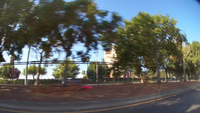
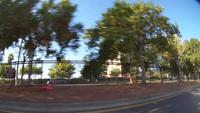
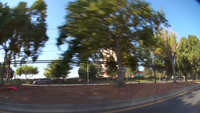
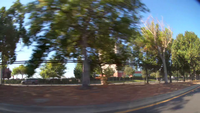
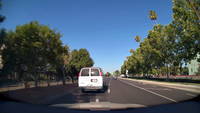
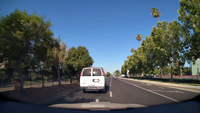
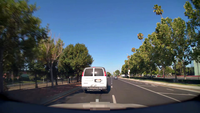
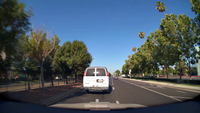
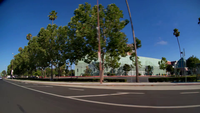
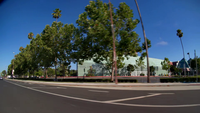
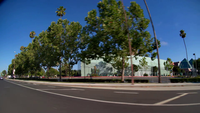
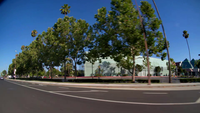
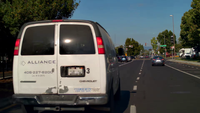
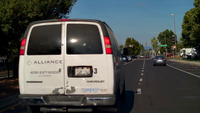
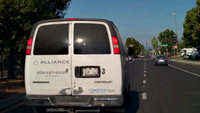
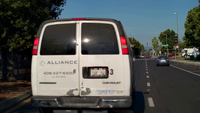

image_frames shape: torch.Size([4, 4, 3, 1080, 1920])


In [38]:
mp.show_images(data["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)
print("image_frames shape:", data["image_frames"].shape)
# (N_cams, N_frames, 3, H, W)

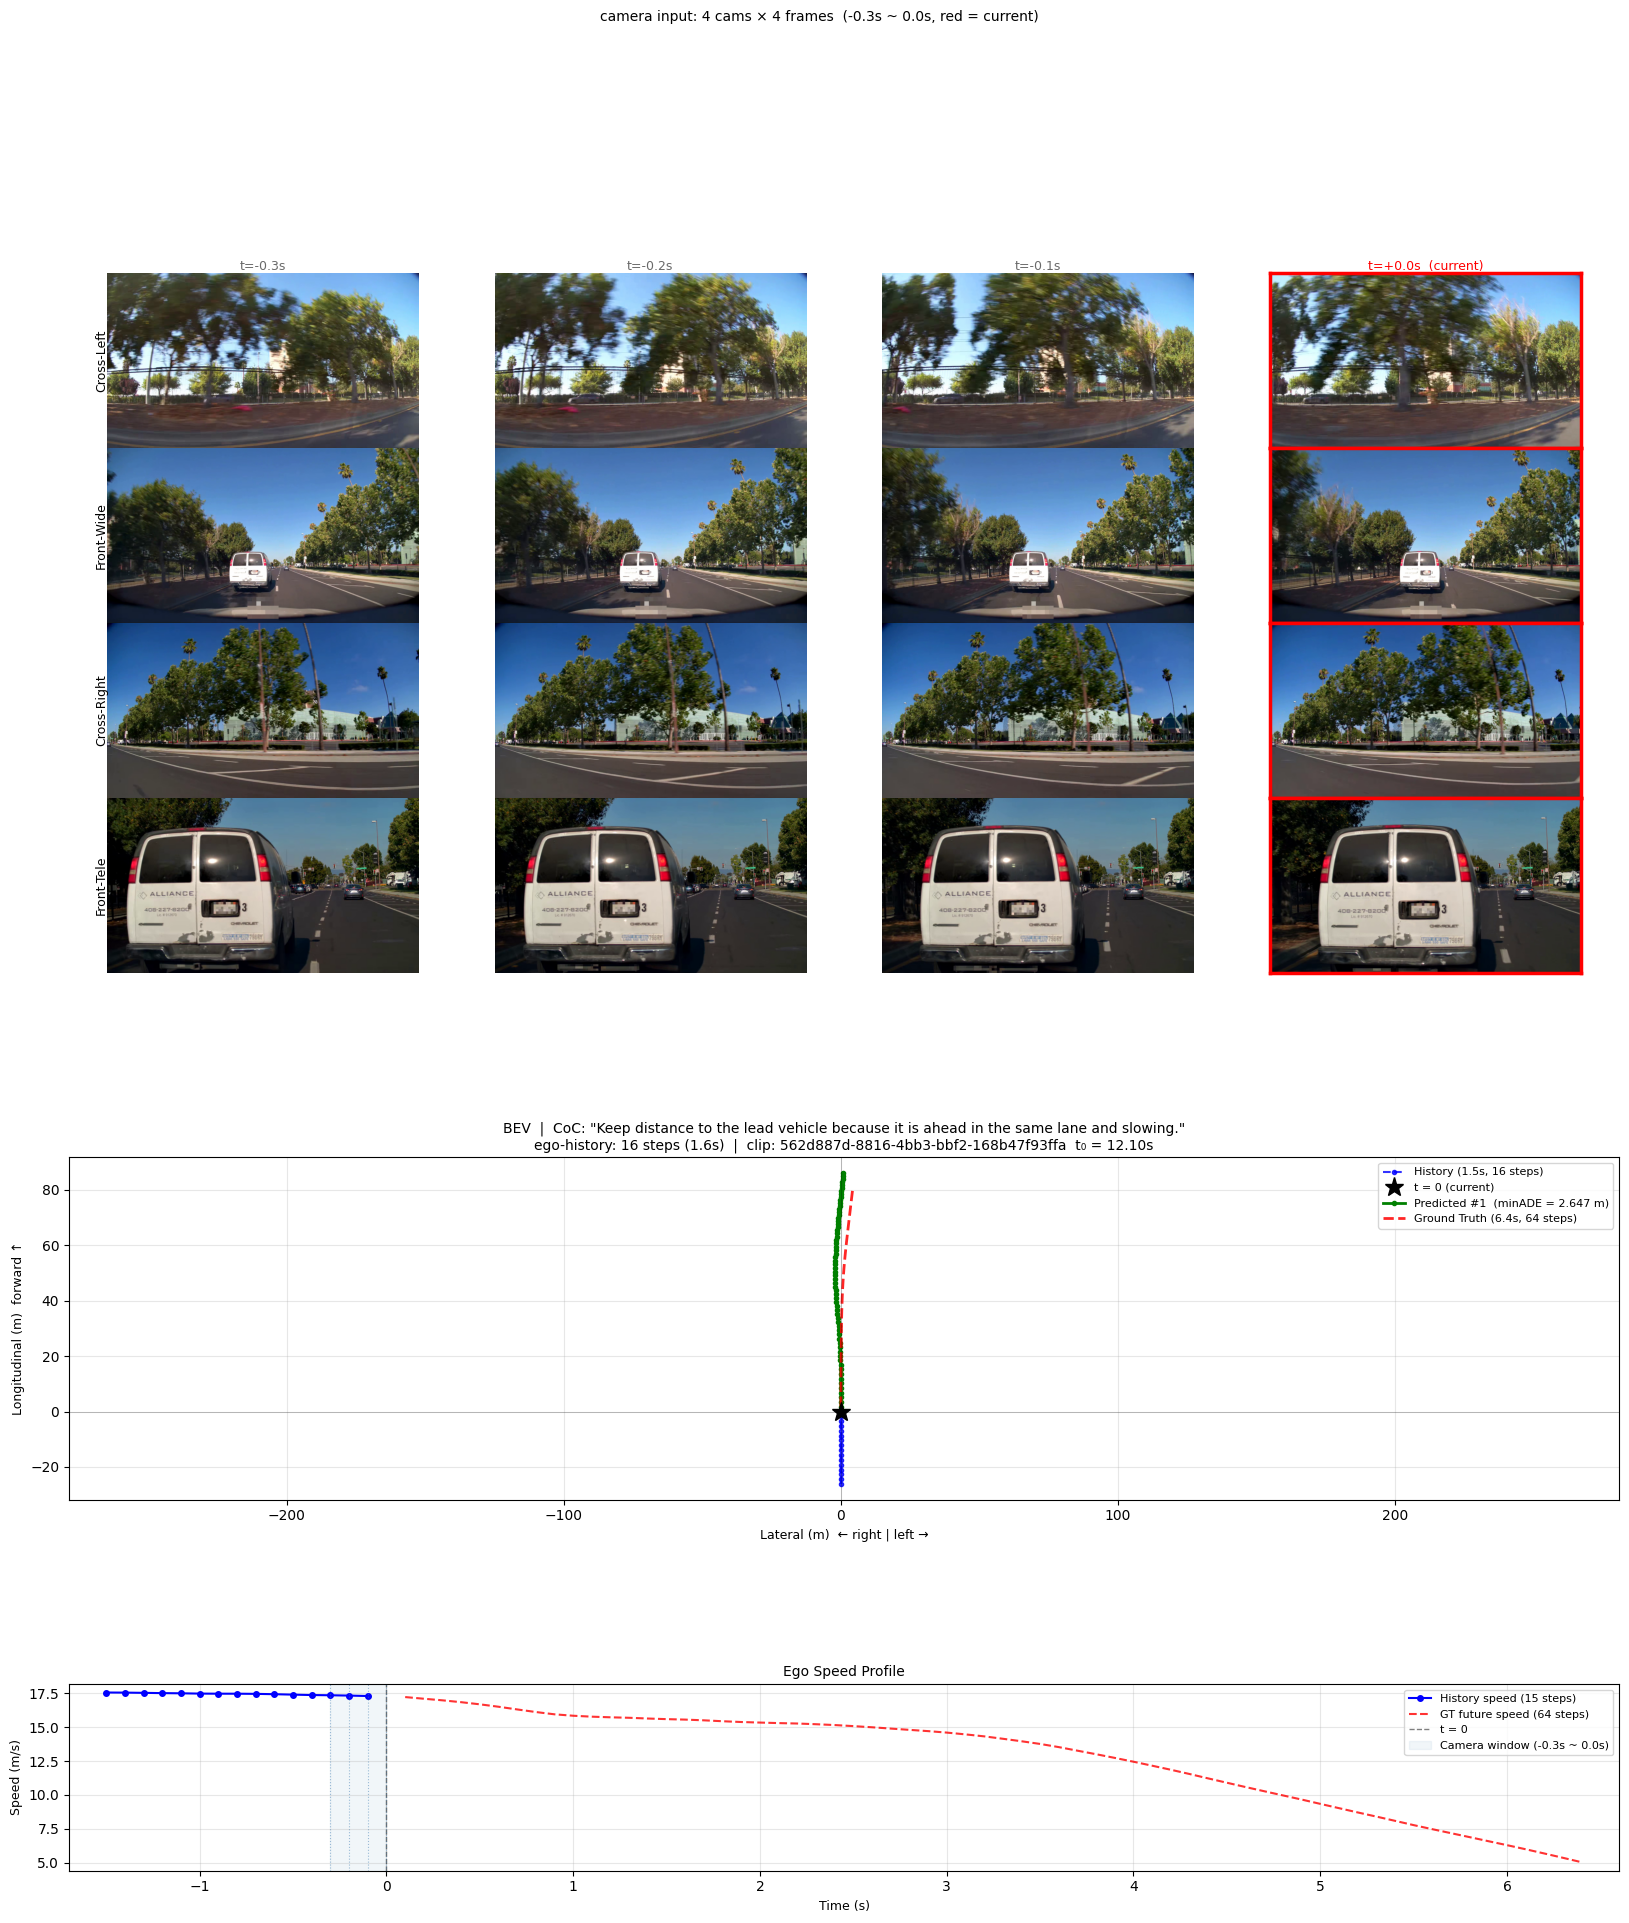

저장됨: /tmp/alpamayo_viz.png


In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


def rotate_90cc(xy):
    return np.stack([-xy[1], xy[0]], axis=0)


# ── 데이터 추출 ───────────────────────────────────────────────────────────────
cam_frames = data["image_frames"].cpu().numpy()           # (N_cam, N_frames, 3, H, W)
N_cams, N_frames = cam_frames.shape[:2]
frames_hwc = cam_frames.transpose(0, 1, 3, 4, 2)         # (N_cam, N_frames, H, W, 3)
cam_names = ["Cross-Left", "Front-Wide", "Cross-Right", "Front-Tele"][:N_cams]

rel_ts   = data["relative_timestamps"].cpu().numpy()      # (N_cam, N_frames)
t_offsets = rel_ts[0] - rel_ts[0, -1]                    # [-0.3, -0.2, -0.1, 0.0]

hist_xyz = data["ego_history_xyz"].cpu().numpy()[0, 0]    # (16, 3)
gt_xyz   = data["ego_future_xyz"].cpu().numpy()[0, 0]     # (64, 3)
hist_xy_rot = rotate_90cc(hist_xyz[:, :2].T)
gt_xy_rot   = rotate_90cc(gt_xyz[:, :2].T)
pred_xy_rots = [
    rotate_90cc(pred_xyz.cpu().numpy()[0, 0, i, :, :2].T)
    for i in range(pred_xyz.shape[2])
]

dt = 0.1
hist_speed    = np.linalg.norm(np.diff(hist_xyz, axis=0), axis=1) / dt
hist_time     = np.arange(-(len(hist_speed)), 0) * dt
gt_speed      = np.linalg.norm(np.diff(np.vstack([[0,0,0], gt_xyz]), axis=0), axis=1) / dt
gt_speed_time = np.arange(len(gt_speed)) * dt + dt

coc_text = extra["cot"][0][0][0] if extra.get("cot") else "N/A"
pred_xy_np    = pred_xyz.cpu().numpy()[0, 0, :, :, :2].transpose(0, 2, 1)
ade_per_sample = np.linalg.norm(pred_xy_np - gt_xyz[:, :2].T[None], axis=1).mean(-1)
min_ade = ade_per_sample.min()

# ── figsize 계산 ──────────────────────────────────────────────────────────────
img_h, img_w = frames_hwc.shape[2], frames_hwc.shape[3]
aspect   = img_h / img_w
cell_w   = 5.0
fig_w    = N_frames * cell_w
img_rows_h = N_cams * cell_w * aspect   # 이미지 섹션 높이
bev_h      = 5.5                        # BEV 서브플롯 높이
spd_h      = 3.0                        # 속도 서브플롯 높이
gap        = 1.0                        # 섹션 간 여백
fig_h = img_rows_h + bev_h + spd_h + gap

# ── 단일 Figure + GridSpec (subfigures 사용 안 함) ────────────────────────────
fig = plt.figure(figsize=(fig_w, fig_h))

# 전체를 3단 행으로: [이미지 행들 | BEV | 속도]
gs_root = gridspec.GridSpec(
    3, 1,
    figure=fig,
    height_ratios=[img_rows_h, bev_h, spd_h],
    hspace=0.45,
)

# ── 이미지 그리드 ─────────────────────────────────────────────────────────────
gs_img = gridspec.GridSpecFromSubplotSpec(
    N_cams, N_frames,
    subplot_spec=gs_root[0],
    wspace=0.0, hspace=0.0,
)

for cam_i in range(N_cams):
    for t_i in range(N_frames):
        ax = fig.add_subplot(gs_img[cam_i, t_i])
        ax.imshow(frames_hwc[cam_i, t_i])
        ax.set_xticks([])
        ax.set_yticks([])

        if t_i == 0:
            ax.set_ylabel(cam_names[cam_i], fontsize=9, rotation=90,
                          va="center", labelpad=4)

        if cam_i == 0:
            is_last = (t_i == N_frames - 1)
            ax.set_title(
                f"t={t_offsets[t_i]:+.1f}s" + ("  (current)" if is_last else ""),
                fontsize=9,
                color="red" if is_last else "dimgray",
                pad=2,
            )

        if t_i == N_frames - 1:
            for sp in ax.spines.values():
                sp.set_edgecolor("red")
                sp.set_linewidth(2.5)
                sp.set_visible(True)
        else:
            for sp in ax.spines.values():
                sp.set_visible(False)

fig.text(
    0.5, 1.0,
    f"camera input: {N_cams} cams × {N_frames} frames  "
    f"({t_offsets[0]:+.1f}s ~ 0.0s, red = current)",
    ha="center", va="bottom", fontsize=10,
    transform=fig.transFigure,
)

# ── BEV ───────────────────────────────────────────────────────────────────────
ax_bev = fig.add_subplot(gs_root[1])
ax_bev.plot(*hist_xy_rot, "b--o", ms=3, lw=1.5, alpha=0.8,
            label=f"History ({abs(hist_time[0]):.1f}s, {len(hist_xyz)} steps)")
ax_bev.plot(0, 0, "k*", ms=14, zorder=6, label="t = 0 (current)")
for i, pxy in enumerate(pred_xy_rots):
    lbl = f"Predicted #{i+1}  (minADE = {min_ade:.3f} m)" if i == 0 else f"Predicted #{i+1}"
    ax_bev.plot(*pxy, "g-o", ms=3, lw=2, label=lbl)
ax_bev.plot(*gt_xy_rot, "r--", lw=2, alpha=0.85,
            label=f"Ground Truth ({len(gt_xyz)*dt:.1f}s, {len(gt_xyz)} steps)")
ax_bev.set_xlabel("Lateral (m)  ← right | left →", fontsize=9)
ax_bev.set_ylabel("Longitudinal (m)  forward ↑", fontsize=9)
ax_bev.set_title(
    f'BEV  |  CoC: "{coc_text}"\n'
    f'ego-history: {len(hist_xyz)} steps ({len(hist_xyz)*dt:.1f}s)  |  '
    f'clip: {data["clip_id"]}  t₀ = {data["t0_us"]/1e6:.2f}s',
    fontsize=10,
)
ax_bev.legend(fontsize=8, loc="best")
ax_bev.axis("equal")
ax_bev.grid(True, alpha=0.3)
ax_bev.axhline(0, color="k", lw=0.5, alpha=0.3)
ax_bev.axvline(0, color="k", lw=0.5, alpha=0.3)

# ── 속도 ──────────────────────────────────────────────────────────────────────
ax_spd = fig.add_subplot(gs_root[2])
ax_spd.plot(hist_time, hist_speed, "b-o", ms=4, lw=1.5,
            label=f"History speed ({len(hist_speed)} steps)")
ax_spd.plot(gt_speed_time, gt_speed, "r--", lw=1.5, alpha=0.8,
            label=f"GT future speed ({len(gt_speed)} steps)")
ax_spd.axvline(0, color="k", lw=1, ls="--", alpha=0.5, label="t = 0")
for t_off in t_offsets:
    ax_spd.axvline(t_off, color="steelblue", lw=0.8, ls=":", alpha=0.5)
ax_spd.axvspan(t_offsets[0], t_offsets[-1], alpha=0.07, color="steelblue",
               label=f"Camera window ({t_offsets[0]:+.1f}s ~ 0.0s)")
ax_spd.set_xlabel("Time (s)", fontsize=9)
ax_spd.set_ylabel("Speed (m/s)", fontsize=9)
ax_spd.set_title("Ego Speed Profile", fontsize=10)
ax_spd.legend(fontsize=8, loc="best")
ax_spd.grid(True, alpha=0.3)
ax_spd.set_xlim(hist_time[0] - 0.2, gt_speed_time[-1] + 0.2)

plt.savefig("/tmp/alpamayo_viz.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"저장됨: /tmp/alpamayo_viz.png")


(np.float64(-25.447352205915376),
 np.float64(1.1993317795451732),
 np.float64(-1.9456953912973405),
 np.float64(56.44444935619831))

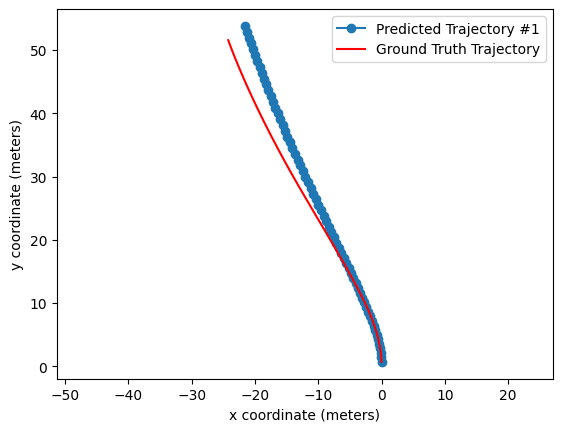

In [8]:
import matplotlib.pyplot as plt


def rotate_90cc(xy):
    # Rotate (x, y) by 90 deg CCW -> (y, -x)
    return np.stack([-xy[1], xy[0]], axis=0)


for i in range(pred_xyz.shape[2]):
    pred_xy = pred_xyz.cpu()[0, 0, i, :, :2].T.numpy()
    pred_xy_rot = rotate_90cc(pred_xy)
    gt_xy = data["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()
    gt_xy_rot = rotate_90cc(gt_xy)
    plt.plot(*pred_xy_rot, "o-", label=f"Predicted Trajectory #{i + 1}")
plt.ylabel("y coordinate (meters)")
plt.xlabel("x coordinate (meters)")
plt.plot(*gt_xy_rot, "r-", label="Ground Truth Trajectory")
plt.legend(loc="best")
plt.axis("equal")

In [9]:
pred_xy = pred_xyz.cpu().numpy()[0, 0, :, :, :2].transpose(0, 2, 1)
diff = np.linalg.norm(pred_xy - gt_xy[None, ...], axis=1).mean(-1)
print("minADE:", diff.min(), "meters")

minADE: 1.5388625 meters
